<a href="https://colab.research.google.com/github/DivineUI/Lab-3/blob/main/Lab_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Lab 3: Neural Networks: Feedforward Networks and the Training Process**

In [3]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)   # use this everywhere so your results are reproducible
np.random.seed(RANDOM_STATE)

print("Running on:", DEVICE)

Running on: cpu


***Section 1 — Inside a Neural Network: From One Neuron to Gradient Descent***

**Part 1.1 — A single neuron is just a line**

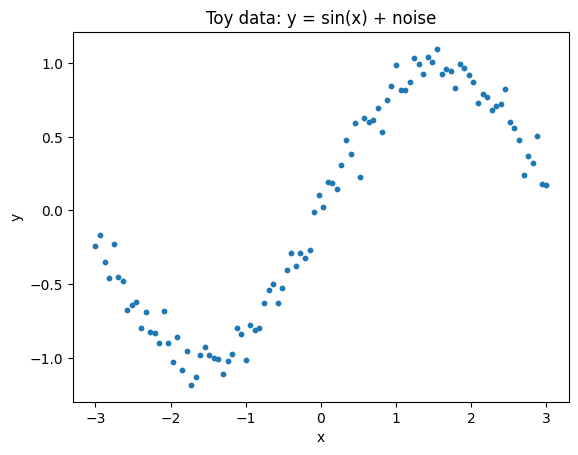

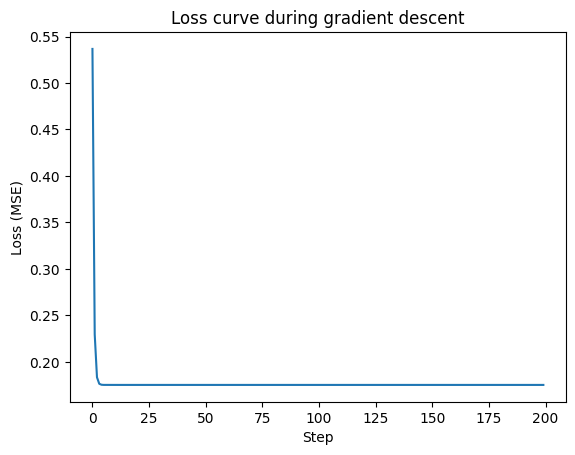

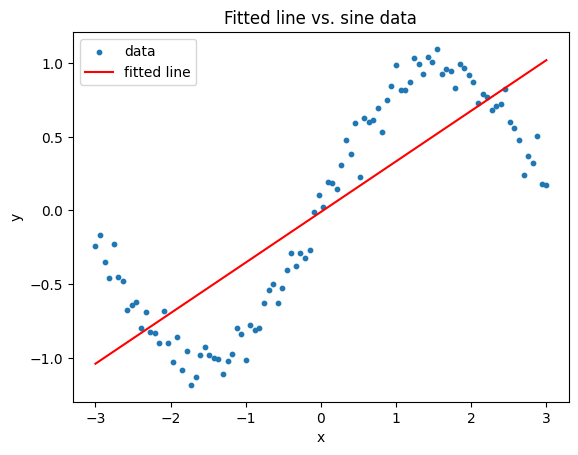

In [5]:
# Generate the toy data
x = np.linspace(-3, 3, 100)
y = np.sin(x) + np.random.normal(0, 0.1, size=x.shape)

plt.scatter(x, y, s=10)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Toy data: y = sin(x) + noise")
plt.show()

# Initialise w and b to small random values.
w = np.random.randn() * 0.01
b = np.random.randn() * 0.01

# Implement ONE gradient-descent step by hand, then loop it for ~200 steps:
lr = 0.1
n_steps = 200
losses = []

for step in range(n_steps):
    y_hat = w * x + b
    loss = np.mean((y_hat - y) ** 2)
    dw = np.mean(2 * (y_hat - y) * x)
    db = np.mean(2 * (y_hat - y))
    w -= lr * dw
    b -= lr * db
    losses.append(loss)

# Plotting the loss curve over the 200 steps
plt.plot(losses)
plt.xlabel("Step")
plt.ylabel("Loss (MSE)")
plt.title("Loss curve during gradient descent")
plt.show()

# Plotting the data with the fitted line on top.
y_pred = w * x + b

plt.scatter(x, y, s=10, label="data")
plt.plot(x, y_pred, color="red", label="fitted line")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Fitted line vs. sine data")
plt.legend()
plt.show()

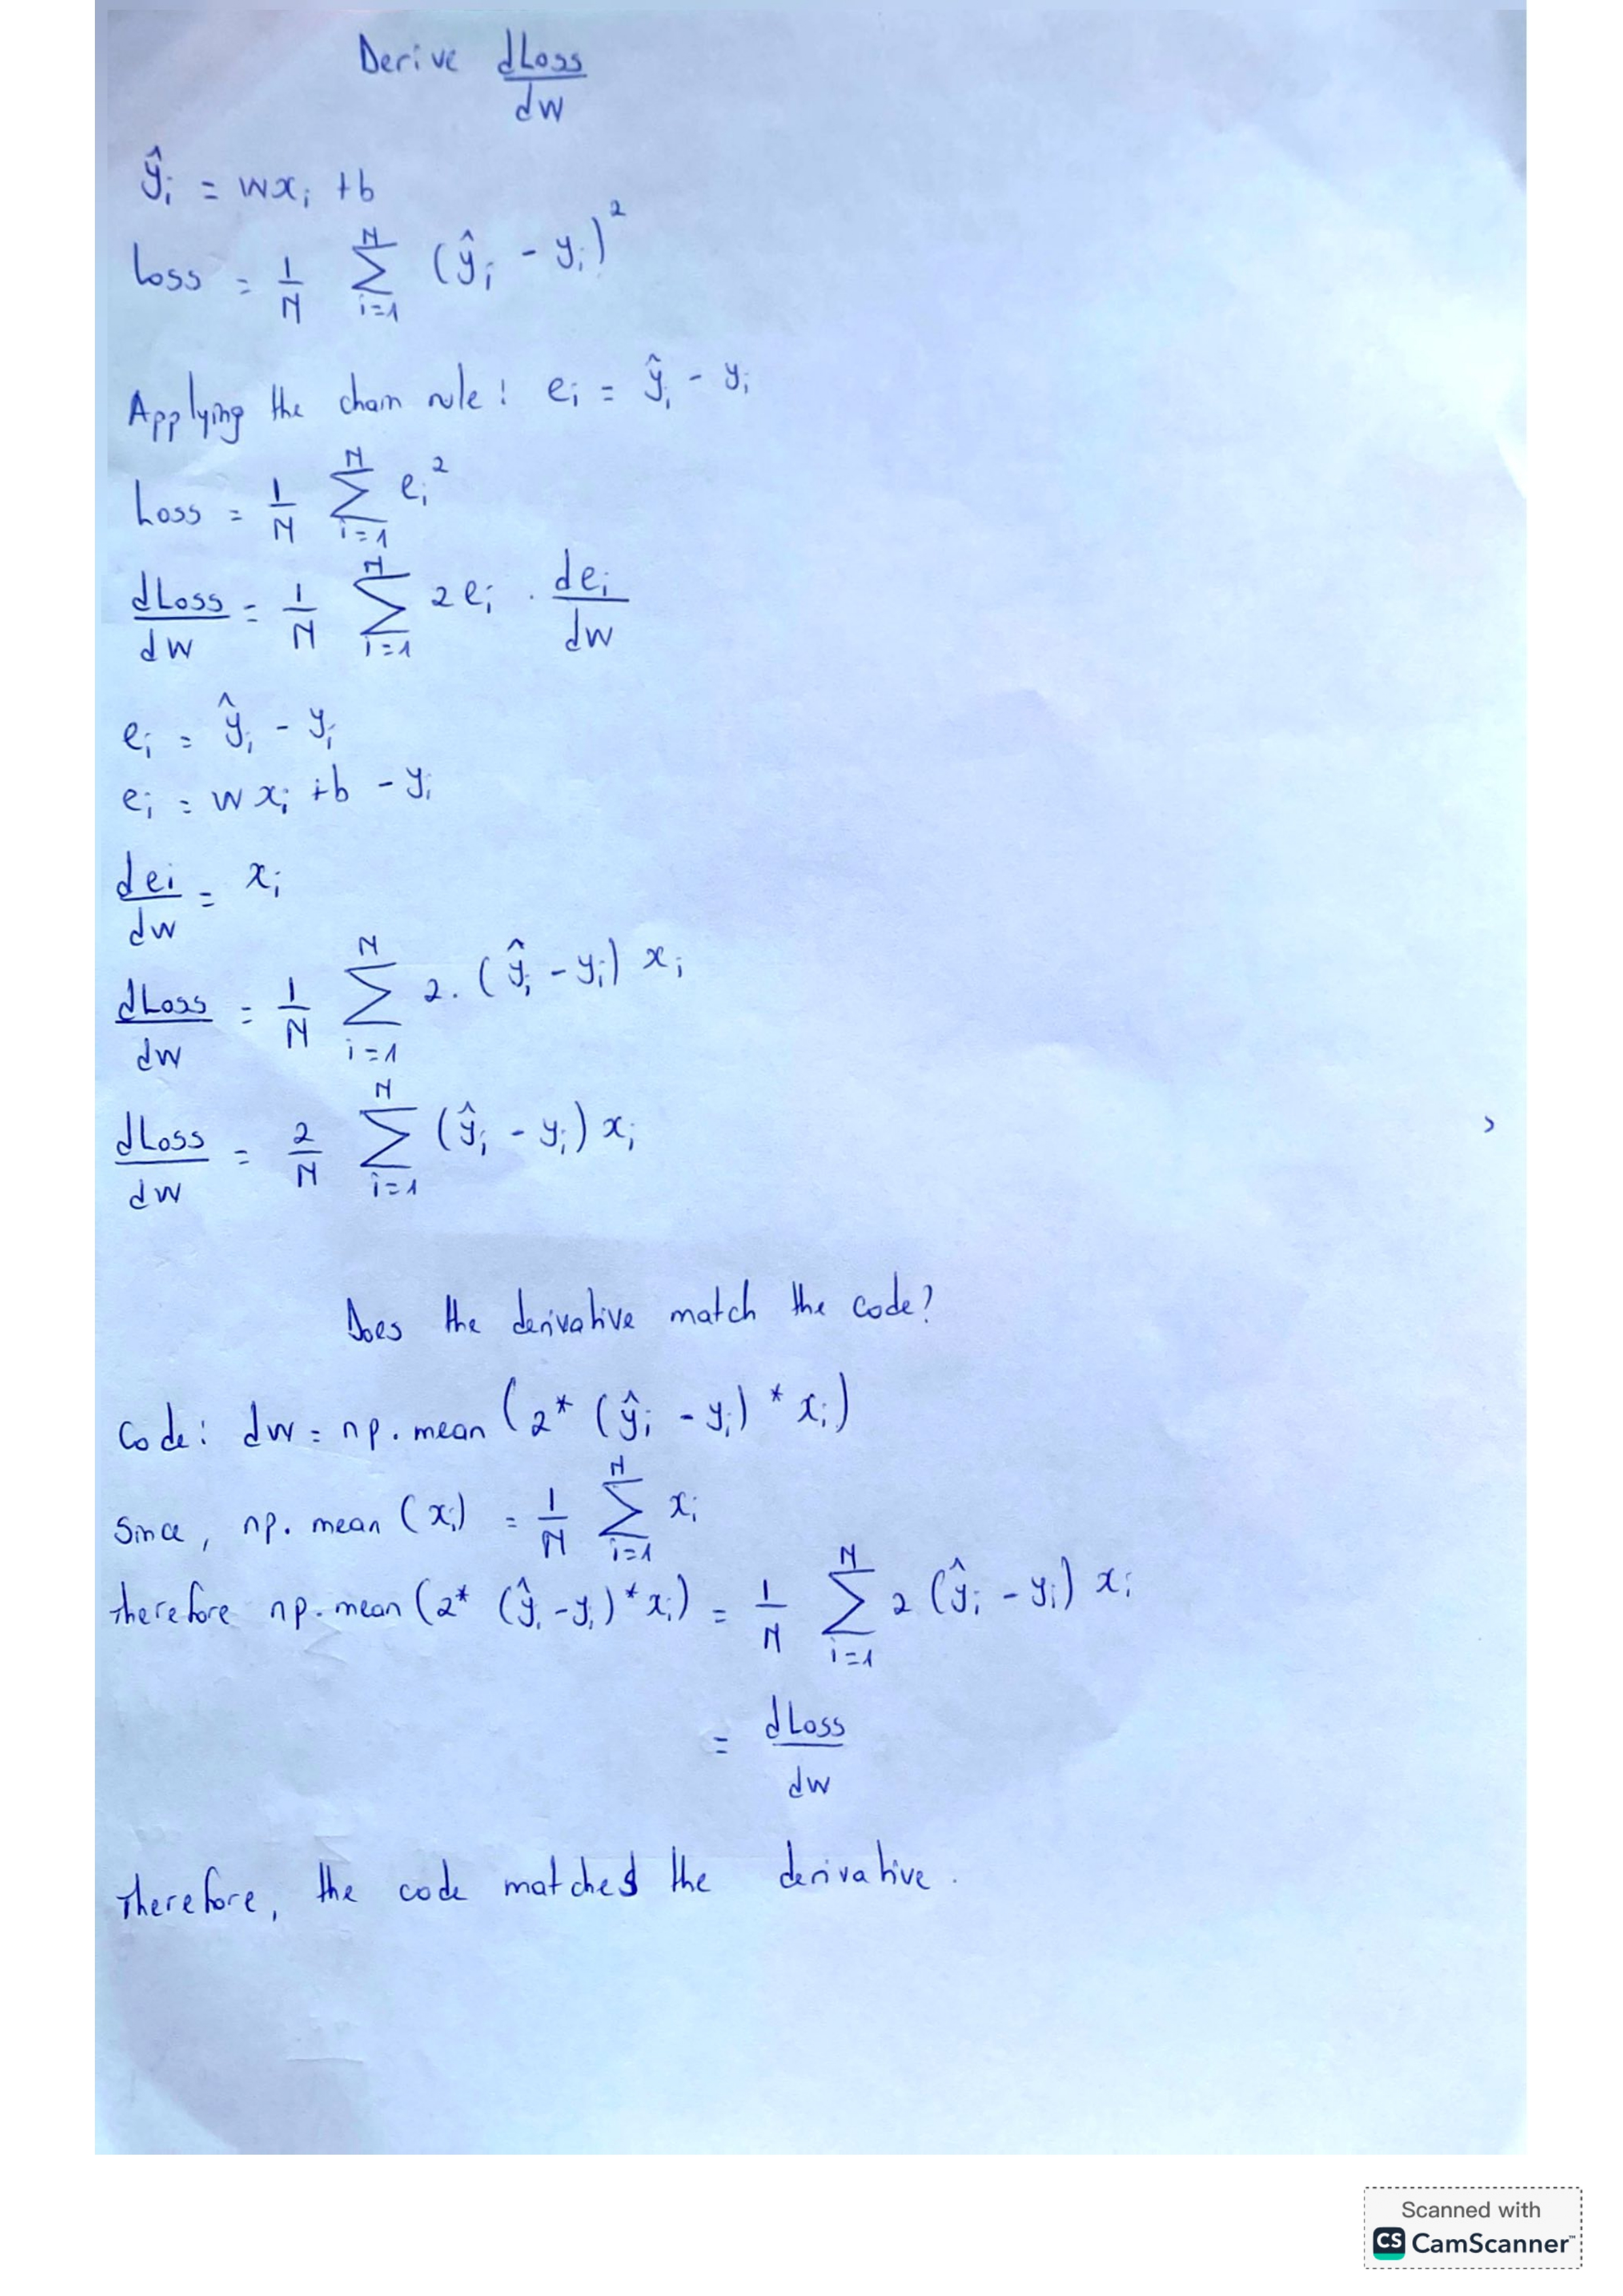

This model training is underfitting because, based on the graph, with blue dots representing training data and red line representing the model's prediction on training data, the model doesn't match the data it was directly trained to fit. Since the model performs poorly on the exact data it was trained on, the  model is too simple to capture the pattern and will not be able to generalize to new data. This happened because a single neuron computes ŷ = wx + b, which is the equation of a straight line; so, no matter how w and b are tuned, this function can only ever produce a straight line, not a curve. Therefore, the  limitation is in the model's structure.

**Part 1.2 — Hidden layers and activations: why depth helps**

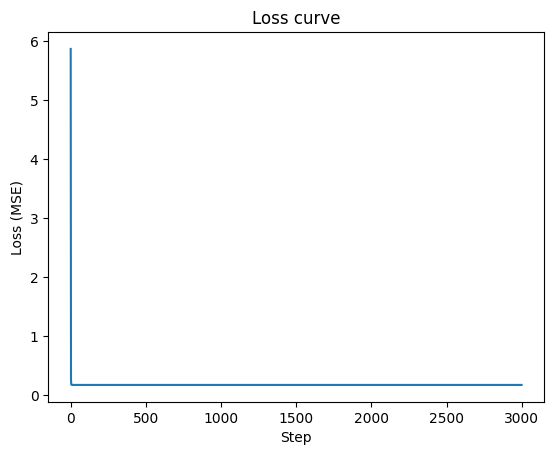

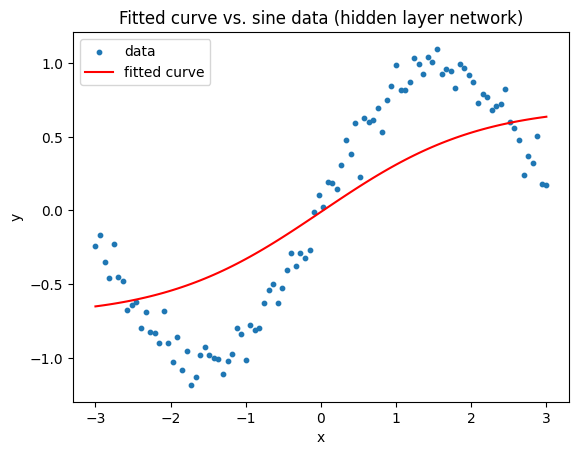

In [6]:
np.random.seed(RANDOM_STATE)
# Initialise parameters
W1 = np.random.randn(1, 8) * 0.5
b1 = np.zeros(8)
W2 = np.random.randn(8, 1) * 0.5
b2 = np.zeros(1)
x_col = x.reshape(-1, 1)
y_col = y.reshape(-1, 1)

lr = 0.1
n_steps = 3000
losses = []

for step in range(n_steps):
  # Forward pass
  z1 = x_col @ W1 + b1
  h = z1
  y_hat = h @ W2 + b2
  loss = np.mean((y_hat - y.reshape(-1,1)) ** 2)

  # Backward pass
  d_yhat = 2 * (y_hat - y_col) / len(y_col)
  dW2 = h.T @ d_yhat
  db2 = d_yhat.sum(axis=0)
  dh = d_yhat @ W2.T
  dz1 = dh * 1
  dW1 = x_col.T @ dz1
  db1 = dz1.sum(axis=0)
  losses.append(loss)
  W1 -= lr * dW1
  b1 -= lr * db1
  W2 -= lr * dW2
  b2 -= lr * db2

# Loss curve
plt.plot(losses)
plt.xlabel("Step")
plt.ylabel("Loss (MSE)")
plt.title("Loss curve")
plt.show()

z1_final = x_col @ W1 + b1
h_final = np.tanh(z1_final)
y_pred = h_final @ W2 + b2

# Final fit over the data
plt.scatter(x, y, s=10, label="data")
plt.plot(x, y_pred, color="red", label="fitted curve")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Fitted curve vs. sine data (hidden layer network)")
plt.legend()
plt.show()

1. Linear layer without an activation function: $$z = x W + b$$

 Three hidden linear layers without activation functions:

 First Layer: $h_1 = x W_1 + b_1$

 Second Layer: $h_2 = h_1 W_2 + b_2$

 Output Layer: $\hat{y} = h_2 W_3 + b_3$


 $$h_2 = (x W_1 + b_1) W_2 + b_2 = x (W_1 W_2) + (b_1 W_2 + b_2)$$

 $$\hat{y} = \left[ x (W_1 W_2) + (b_1 W_2 + b_2) \right] W_3 + b_3$$

 $$\hat{y} = x (W_1 W_2 W_3) + (b_1 W_2 W_3 + b_2 W_3 + b_3)$$

$W_{\text{T}} = W_1 W_2 W_3$
$b_{\text{T}} = b_1 W_2 W_3 + b_2 W_3 + b_3$

$$\hat{y} = x W_{\text{T}} + b_{\text{T}}$$

This equation is in the exact same form as a single linear layer($\hat{y} = x w + b$), this means the model can only ever represent straight lines. Non-linear activation functions like tanh break this linearity, allowing deep networks to approximate complex non-linear curves.

2. Each neuron acts as a shifted and scaled tanh S-curve that active over different regions of $x$, allowing the network to sum them together to reconstruct the non-linear sine curve.

3. **Backpropagation** is the method of using the chain rule to calculate gradients from the output layer backward to input layers, determining how much each weight needs to change to minimize loss.




**Part 1.3 — The learning rate: too cold, too hot, just right**

/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:127: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/tmp/ipykernel_2905/339951058.py:15: RuntimeWarning: overflow encountered in square
  loss = np.mean((y_hat - y_col) ** 2)
/tmp/ipykernel_2905/339951058.py:21: RuntimeWarning: overflow encountered in matmul
  dh = d_yhat @ W2.T
/tmp/ipykernel_2905/339951058.py:22: RuntimeWarning: invalid value encountered in multiply
  dz1 = dh * (1 - np.tanh(z1) ** 2)
/usr/local/lib/python3.12/dist-packages/matplotlib/scale.py:253: RuntimeWarning: overflow encountered in power
  return np.power(self.base, values)


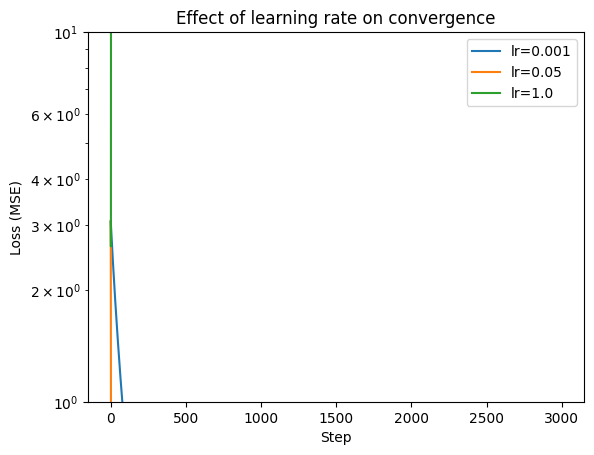

In [7]:
# Part 1.2 training loop in a function train_toy
def train_toy(lr, steps=3000):
    np.random.seed(RANDOM_STATE)
    W1 = np.random.randn(1, 8) * 0.5
    b1 = np.zeros(8)
    W2 = np.random.randn(8, 1) * 0.5
    b2 = np.zeros(1)

    losses = []
    for step in range(steps):
        # forward pass
        z1 = x_col @ W1 + b1
        h = np.tanh(z1)
        y_hat = h @ W2 + b2
        loss = np.mean((y_hat - y_col) ** 2)

        # backward pass
        d_yhat = 2 * (y_hat - y_col) / len(y_col)
        dW2 = h.T @ d_yhat
        db2 = d_yhat.sum(axis=0)
        dh = d_yhat @ W2.T
        dz1 = dh * (1 - np.tanh(z1) ** 2)
        dW1 = x_col.T @ dz1
        db1 = dz1.sum(axis=0)

        # update
        losses.append(loss)
        W1 -= lr * dW1
        b1 -= lr * db1
        W2 -= lr * dW2
        b2 -= lr * db2

    return losses

# Run it with THREE learning rates
losses_low = train_toy(lr=0.001)
losses_mid = train_toy(lr=0.05)
losses_high = train_toy(lr=1.0)

# Plotting
plt.plot(losses_low, label="lr=0.001")
plt.plot(losses_mid, label="lr=0.05")
plt.plot(losses_high, label="lr=1.0")
plt.yscale("log")
plt.xlabel("Step")
plt.ylabel("Loss (MSE)")
plt.title("Effect of learning rate on convergence")
plt.legend()
plt.show()

1. **lr=0.001**: Shows a slow decrease in loss which gives an inefficient covergence.
2. **lr=0.05**: Shows a rapid and continuous decrease in loss. Here the model gives an optimal convergence without undershooting or overshooting.
3. **lr=1.0**: the model increases rapidly which causes overshooting

When the learning rate is set to 1.0, the gradient steps take massive jumps across the loss landscape, and instead of moving toward the minimum, the weights blow up toward infinity